In [1]:
import pandas as pd

In [2]:
#Loading the WHO PM 2.5 data
df_who = pd.read_excel("who_pm25.xlsx", sheet_name="Update 2024 (V6.1)")

In [3]:
print(df_who.head())

  who_region iso3 country_name          city    year  \
0      4_Eur  ESP        Spain  A Coruna/ESP  2013.0   
1      4_Eur  ESP        Spain  A Coruna/ESP  2014.0   
2      4_Eur  ESP        Spain  A Coruna/ESP  2015.0   
3      4_Eur  ESP        Spain  A Coruna/ESP  2016.0   
4      4_Eur  ESP        Spain  A Coruna/ESP  2017.0   

                                             version  pm10_concentration  \
0  V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...              23.238   
1           V6.0  (2023), V6.0  (2023), V6.0  (2023)              27.476   
2  V6.0  (2023), V6.0  (2023), V6.0  (2023), V6.0...              25.515   
3  V6.0  (2023), V6.0  (2023), V6.0  (2023), V6.0...              23.057   
4  V6.0  (2023), V6.0  (2023), V6.0  (2023), V6.0...              26.849   

   pm25_concentration  no2_concentration  pm10_tempcov  pm25_tempcov  \
0              11.491             28.841          87.0          46.0   
1              15.878             19.575          96.0        

In [4]:
print(df_who.columns)

Index(['who_region', 'iso3', 'country_name', 'city', 'year', 'version',
       'pm10_concentration', 'pm25_concentration', 'no2_concentration',
       'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'type_of_stations',
       'reference', 'web_link', 'population', 'population_source', 'latitude',
       'longitude', 'who_ms'],
      dtype='object')


In [5]:
df_who = df_who[['country_name', 'year', 'pm25_concentration']]

In [6]:
print(df_who.head())

  country_name    year  pm25_concentration
0        Spain  2013.0              11.491
1        Spain  2014.0              15.878
2        Spain  2015.0              14.004
3        Spain  2016.0              13.160
4        Spain  2017.0              14.114


In [7]:
#Removing missing values
df_who = df_who.dropna()
print(df_who.shape)

(21729, 3)


In [8]:
#Filtering recent years
df_who = df_who[df_who['year'] >= 2015]

In [9]:
print(df_who.shape)

(16811, 3)


In [10]:
#Converting to country-level
df_who_country = df_who.groupby('country_name')['pm25_concentration'].mean().reset_index()

In [11]:
df_who_country.rename(columns={'pm25_concentration': 'avg_pm25'}, inplace=True)

In [12]:

print(df_who_country.head())

  country_name    avg_pm25
0  Afghanistan  119.774000
1      Albania   16.603176
2      Algeria   21.533000
3    Argentina   13.679429
4    Australia    7.292806


In [13]:
print(df_who_country.shape)

(107, 2)


In [14]:
print(df_who.shape)

(16811, 3)


In [15]:
#Loading the population dataset
df_pop = pd.read_csv("population.csv", skiprows=4)

In [16]:
print(df_pop.head())

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name Indicator Code  1960  \
0  Population density (people per sq. km of land ...    EN.POP.DNST   NaN   
1  Population density (people per sq. km of land ...    EN.POP.DNST   NaN   
2  Population density (people per sq. km of land ...    EN.POP.DNST   NaN   
3  Population density (people per sq. km of land ...    EN.POP.DNST   NaN   
4  Population density (people per sq. km of land ...    EN.POP.DNST   NaN   

         1961        1962        1963        1964        1965  ...  \
0  308.766667  312.888889  316.677778  320.105556  323.277778  ...   
1   12.036017   12.363810   12.703964   13.060764   13.432961  ...   
2   14.127046   14.418849   14.725614   15.0

In [17]:
print(df_pop.columns)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')


In [18]:
print(df_pop.shape)

(266, 71)


In [19]:
#removing the junk column Unnamed: 70
df_pop = df_pop.drop(columns=['Unnamed: 70'])

In [20]:
#Future years (2024, 2025) are empty, so removing it aswell
df_pop = df_pop.drop(columns=['2024', '2025'])

In [21]:
#Right now my data looks like:

#Country | 1960 | 1961 | 1962 | ... | 2023

# This is called wide format 
# I CANNOT merge this with WHO data like this
# So, Converting to LONG FORMAT

df_pop_long = df_pop.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='population_density'
)

In [22]:
# What this does

#Converts this:

#India | 1960 | 1961 | 1962 ...

#Into:

#India | 1960 | value  
#India | 1961 | value  
#India | 1962 | value  

In [23]:
#Cleaning it further
# Converting year to numeric
df_pop_long['year'] = pd.to_numeric(df_pop_long['year'], errors='coerce')

In [24]:
# Drop missing values
df_pop_long = df_pop_long.dropna()

In [25]:
#Verifying
print(df_pop_long.head())

                    Country Name Country Code    year population_density
798                        Aruba          ABW  1961.0         308.766667
799  Africa Eastern and Southern          AFE  1961.0          12.036017
800                  Afghanistan          AFG  1961.0          14.127046
801   Africa Western and Central          AFW  1961.0          11.021477
802                       Angola          AGO  1961.0           4.252493


In [26]:
print(df_pop_long.shape)

(15296, 4)


In [27]:
#Column names don’t match yet:

#country_name (WHO)
#Country Name (population)

# Fixing this now (very important for merge):

df_pop_long = df_pop_long.rename(columns={
    'Country Name': 'country_name'
})

In [28]:
#Making all country names lowercase to avoid merge issues:
df_pop_long['country_name'] = df_pop_long['country_name'].str.lower()

In [29]:
print(df_pop_long.shape)

(15296, 4)


In [30]:
#Checking if the renaming of the "Country Name" column got fixed
print(df_pop_long.head())

                    country_name Country Code    year population_density
798                        aruba          ABW  1961.0         308.766667
799  africa eastern and southern          AFE  1961.0          12.036017
800                  afghanistan          AFG  1961.0          14.127046
801   africa western and central          AFW  1961.0          11.021477
802                       angola          AGO  1961.0           4.252493


In [31]:
# Yes, it got fixed

In [32]:
#Now loading my 3rd datset gdp_per_capita
df_gdp = pd.read_csv("gdp_per_capita.csv", skiprows=4)

In [33]:
print(df_gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [34]:
print(df_gdp.columns)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')


In [35]:
print(df_gdp.shape)

(266, 71)


In [36]:
#Removing junk columns
df_gdp = df_gdp.drop(columns=['Unnamed: 70'], errors='ignore')
df_gdp = df_gdp.drop(columns=['2024', '2025'], errors='ignore')

In [37]:
#Converting to LONG format
df_gdp_long = df_gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='gdp_per_capita'
)

In [38]:
#Cleaning it 
# Converting year to numeric year
df_gdp_long['year'] = pd.to_numeric(df_gdp_long['year'], errors='coerce')

# Droping missing values
df_gdp_long = df_gdp_long.dropna()

In [39]:
#fixing column names
df_gdp_long = df_gdp_long.rename(columns={
    'Country Name': 'country_name'
})

# Standardize text
df_gdp_long['country_name'] = df_gdp_long['country_name'].str.lower()

In [40]:
#verifying
print(df_gdp_long.head())

                    country_name Country Code    year gdp_per_capita
533  africa eastern and southern          AFE  1960.0     186.089204
535   africa western and central          AFW  1960.0     121.936832
541                    argentina          ARG  1960.0     778.251707
545                    australia          AUS  1960.0    1813.431099
546                      austria          AUT  1960.0     939.914815


In [41]:
print(df_gdp_long.shape)

(14321, 4)


In [42]:
# Making sure WHO dataset also matches 
df_who_country['country_name'] = df_who_country['country_name'].str.lower()

In [43]:
#Merging datasets
#Merging WHO + Population
df_merged = pd.merge(
    df_who_country,
    df_pop_long,
    on=['country_name'],
    how='inner'
)


In [44]:
# Now merging GDP
df_final = pd.merge(
    df_merged,
    df_gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

In [45]:
# Clean final dataset
df_final = df_final.dropna()

In [46]:
# verifying
print(df_final.head())

  country_name  avg_pm25 Country Code_x    year population_density  \
0  afghanistan   119.774            AFG  2000.0          30.863847   
1  afghanistan   119.774            AFG  2001.0          31.099929   
2  afghanistan   119.774            AFG  2002.0          32.776961   
3  afghanistan   119.774            AFG  2003.0          34.854344   
4  afghanistan   119.774            AFG  2004.0           36.12323   

  Country Code_y gdp_per_capita  
0            AFG     174.930991  
1            AFG     138.706822  
2            AFG     178.954088  
3            AFG     198.871116  
4            AFG     221.763654  


In [47]:
print(df_final.shape)

(4972, 7)


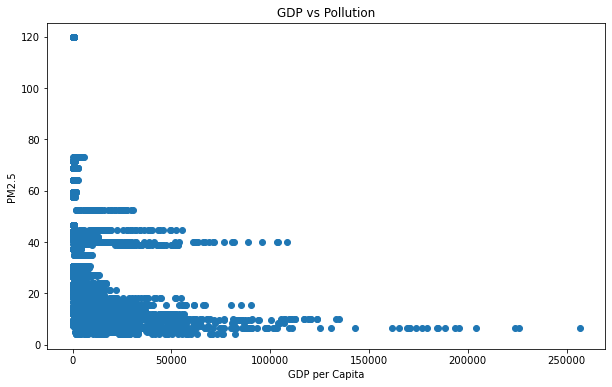

In [56]:
import matplotlib.pyplot as plt

# GDP vs Pollution
plt.figure(figsize=(10,6))
plt.scatter(df_final['gdp_per_capita'], df_final['avg_pm25'])
plt.xlabel("GDP per Capita")
plt.ylabel("PM2.5")
plt.title("GDP vs Pollution")
plt.show()

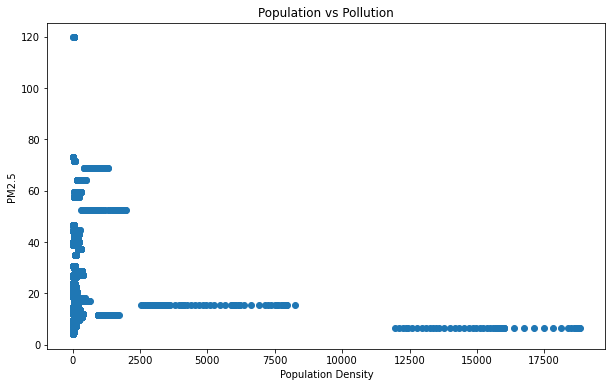

In [57]:
# Population vs Pollution
plt.figure(figsize=(10,6))
plt.scatter(df_final['population_density'], df_final['avg_pm25'])
plt.xlabel("Population Density")
plt.ylabel("PM2.5")
plt.title("Population vs Pollution")
plt.show()

In [58]:
# Correlation
df_final[['avg_pm25', 'population_density', 'gdp_per_capita']].corr()

,avg_pm25
avg_pm25,1.0


In [59]:
#checking data types
print(df_final.dtypes)

country_name           object
avg_pm25              float64
Country Code_x         object
year                  float64
population_density     object
Country Code_y         object
gdp_per_capita         object
dtype: object


In [60]:
#Convert to numeric
df_final['population_density'] = pd.to_numeric(df_final['population_density'], errors='coerce')
df_final['gdp_per_capita'] = pd.to_numeric(df_final['gdp_per_capita'], errors='coerce')

In [61]:
#removing nan values again
df_final = df_final.dropna()

In [62]:
# verifying types
print(df_final.dtypes)

country_name           object
avg_pm25              float64
Country Code_x         object
year                  float64
population_density    float64
Country Code_y         object
gdp_per_capita        float64
dtype: object


In [71]:
#checking correlation again 

df_final[['avg_pm25', 'population_density', 'gdp_per_capita']].corr()

,avg_pm25,population_density,gdp_per_capita
avg_pm25,1.000000,-0.088137,-0.270878
population_density,-0.088137,1.000000,0.509156
gdp_per_capita,-0.270878,0.509156,1.000000


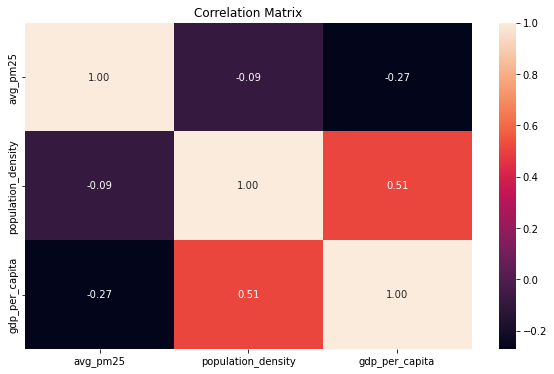

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_final[['avg_pm25', 'population_density', 'gdp_per_capita']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

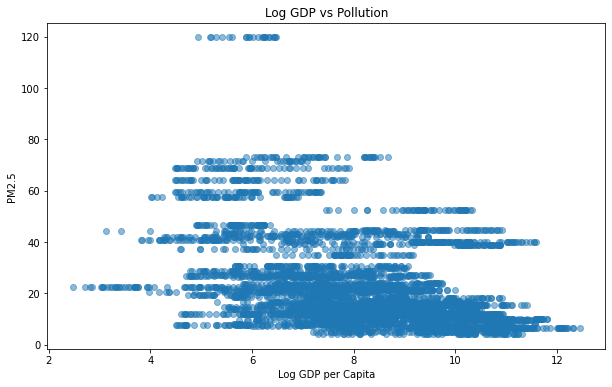

In [73]:
import numpy as np

df_final['log_gdp'] = np.log(df_final['gdp_per_capita'])

plt.figure(figsize=(10,6))
plt.scatter(df_final['log_gdp'], df_final['avg_pm25'], alpha=0.5)
plt.xlabel("Log GDP per Capita")
plt.ylabel("PM2.5")
plt.title("Log GDP vs Pollution")
plt.show()

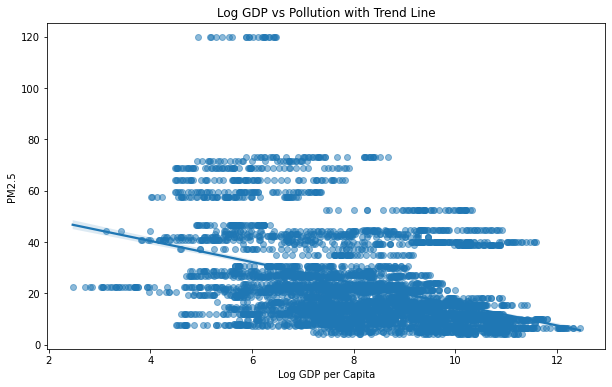

In [74]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(x='log_gdp', y='avg_pm25', data=df_final, scatter_kws={'alpha':0.5})

plt.xlabel("Log GDP per Capita")
plt.ylabel("PM2.5")
plt.title("Log GDP vs Pollution with Trend Line")
plt.show()

In [76]:
df_final['gdp_group'] = pd.qcut(
    df_final['gdp_per_capita'], 
    3, 
    labels=['Low', 'Medium', 'High']
)

In [77]:
df_final.groupby('gdp_group')['avg_pm25'].mean()

gdp_group
Low       32.832061
Medium    21.223734
High      16.453879
Name: avg_pm25, dtype: float64

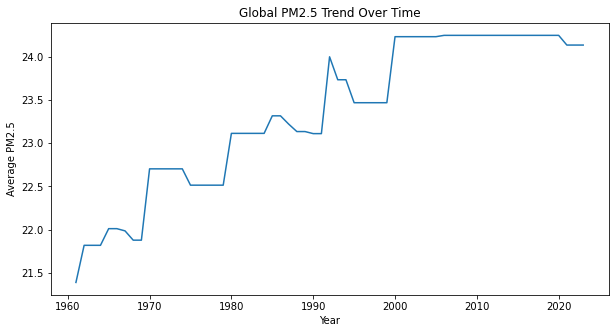

In [87]:
# time Trend
plt.figure(figsize=(10,5))
df_final.groupby('year')['avg_pm25'].mean().plot()

plt.title("Global PM2.5 Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")

plt.show()

In [79]:
# Top polluted countries

df_final.groupby('country_name')['avg_pm25'].mean().sort_values(ascending=False).head(10)

country_name
afghanistan    119.774000
mongolia        73.000000
tajikistan      71.517000
bangladesh      68.775030
india           64.329079
pakistan        59.592167
uganda          57.635333
bahrain         52.407333
madagascar      46.750000
kuwait          44.581333
Name: avg_pm25, dtype: float64

In [82]:
top_polluted = df_final.groupby('country_name')['avg_pm25'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

In [83]:
colors = ['red' if x == top_polluted.max() else 'blue' for x in top_polluted]

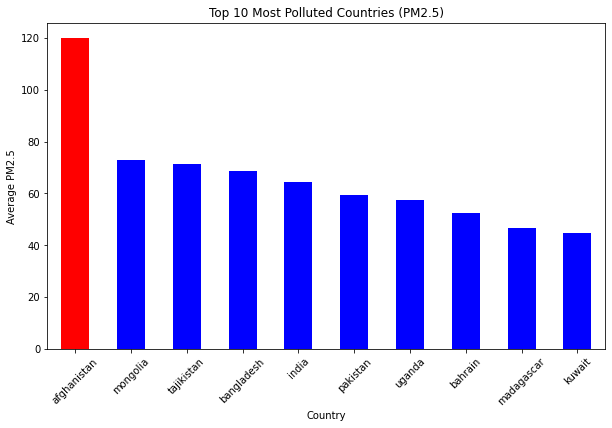

In [84]:
plt.figure(figsize=(10,6))
top_polluted.plot(kind='bar', color=colors)

plt.title("Top 10 Most Polluted Countries (PM2.5)")
plt.xlabel("Country")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=45)
plt.show()

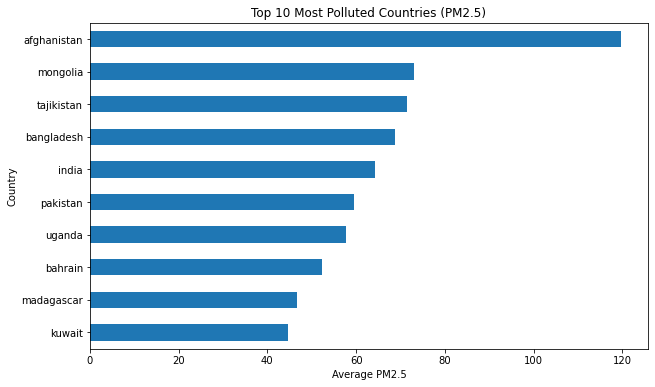

In [85]:
plt.figure(figsize=(10,6))
top_polluted.sort_values().plot(kind='barh')

plt.title("Top 10 Most Polluted Countries (PM2.5)")
plt.xlabel("Average PM2.5")
plt.ylabel("Country")

plt.show()

In [88]:
# Now exporting my final dataset tha I've worked on to my local device(Laptop) , as I want to upload this to Tableau
df_final.to_csv("final_dataset.csv", index=False)